In [ ]:
from google.colab import files

uploaded = files.upload()

Saving employee_performance.csv to employee_performance.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
df = pd.read_csv("employee_performance.csv")

df.head()

,Employee_ID,Age,Gender,Department,Experience_Years,Performance_Score,Salary
0,E0524,49,Female,Operations,5.6,67.8,33013.0
1,E0603,55,Female,Sales,5.5,NaN,42640.0
2,E0527,29,Female,Sales,10.7,68.8,72180.0
3,E0032,30,Female,Operations,9.8,NaN,65750.0
4,E0617,58,Male,Sales,11.5,72.8,74830.0


In [ ]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nDescription:")
df.describe()

Shape: (1020, 7)

Columns:
Index(['Employee_ID', 'Age', 'Gender', 'Department', 'Experience_Years',
       'Performance_Score', 'Salary'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   Age                1020 non-null   int64  
 2   Gender             1020 non-null   object 
 3   Department         1020 non-null   object 
 4   Experience_Years   988 non-null    float64
 5   Performance_Score  990 non-null    float64
 6   Salary             1020 non-null   float64
dtypes: float64(3), int64(1), object(3)
memory usage: 55.9+ KB

Description:


,Age,Experience_Years,Performance_Score,Salary
count,1020.000000,988.000000,990.000000,1020.000000
mean,40.898039,7.209919,69.755657,52905.790196
std,11.160063,3.070575,9.935075,33016.717394
min,22.000000,0.000000,37.600000,5000.000000
25%,31.000000,5.200000,63.025000,38867.750000
50%,42.000000,7.250000,70.050000,50595.500000
75%,50.000000,9.200000,76.675000,60984.250000
max,59.000000,16.800000,97.500000,400000.000000


In [ ]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Experience_Years,32
Performance_Score,30
Salary,0


In [ ]:
df["Performance_Score"] = df["Performance_Score"].fillna(
    df["Performance_Score"].mean()
)

df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Experience_Years,32
Performance_Score,0
Salary,0


In [ ]:
df["Experience_Years"] = df["Experience_Years"].fillna(
    df["Experience_Years"].mean()
)

df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Department,0
Experience_Years,0
Performance_Score,0
Salary,0


In [ ]:
def calculate_bonus(salary):
    return salary * 0.10

def is_top_performer(score):
    return score > 80

print("Bonus for ₹50,000 salary:", calculate_bonus(50000))
print("Is 85 a top performer?", is_top_performer(85))

Bonus for ₹50,000 salary: 5000.0
Is 85 a top performer? True


In [ ]:
class EmployeeAnalyzer:

    def __init__(self, df):
        self.df = df

    def average_salary(self):
        return self.df["Salary"].mean()

    def highest_salary(self):
        return self.df["Salary"].max()

    def lowest_salary(self):
        return self.df["Salary"].min()

In [ ]:
analyzer = EmployeeAnalyzer(df)

print("Average Salary:", analyzer.average_salary())
print("Highest Salary:", analyzer.highest_salary())
print("Lowest Salary:", analyzer.lowest_salary())

Average Salary: 52905.79019607843
Highest Salary: 400000.0
Lowest Salary: 5000.0


In [ ]:
salary_array = np.array(df["Salary"])

print("Mean:", np.mean(salary_array))
print("Standard Deviation:", np.std(salary_array))
print("Maximum:", np.max(salary_array))
print("Minimum:", np.min(salary_array))

Mean: 52905.79019607843
Standard Deviation: 33000.528759832494
Maximum: 400000.0
Minimum: 5000.0


In [ ]:
updated_salary = salary_array + 5000

print(updated_salary[:10])

[38013. 47640. 77180. 70750. 79830. 30481. 77051. 50430. 42906. 50616.]


In [ ]:
high_earners = [
    salary for salary in df["Salary"]
    if salary > 70000
]

print("Number of High Earners:", len(high_earners))

Number of High Earners: 116


In [ ]:
department_avg = {
    dept: df[df["Department"] == dept]["Salary"].mean()
    for dept in df["Department"].unique()
}

print(department_avg)

{'Operations': np.float64(47194.65909090909), 'Sales': np.float64(51110.97252747253), 'IT': np.float64(54279.857142857145), 'Marketing': np.float64(57349.69680851064), 'HR': np.float64(55068.31288343558), 'Finance': np.float64(52622.16959064327)}


In [ ]:
df.groupby("Department")["Salary"].mean()

,Salary
Department,
Finance,52622.169591
HR,55068.312883
IT,54279.857143
Marketing,57349.696809
Operations,47194.659091
Sales,51110.972527


In [ ]:
df.groupby("Gender")["Salary"].mean()

,Salary
Gender,
Female,52695.703340
Male,53115.054795


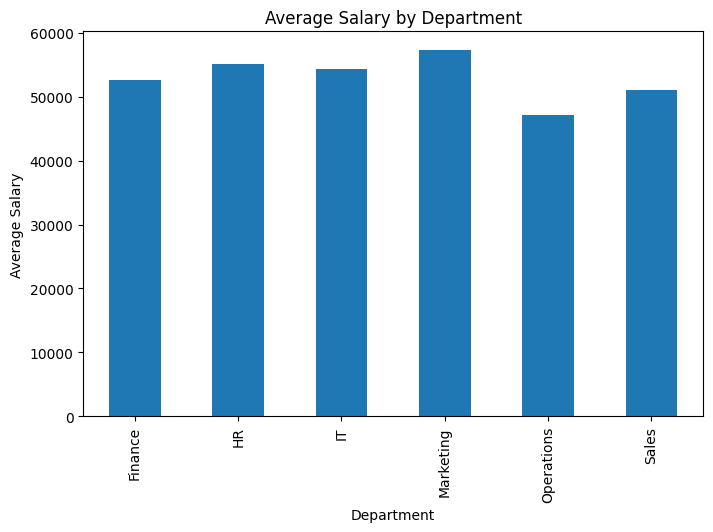

In [ ]:
dept_salary = df.groupby("Department")["Salary"].mean()

plt.figure(figsize=(8,5))
dept_salary.plot(kind="bar")
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary")
plt.show()

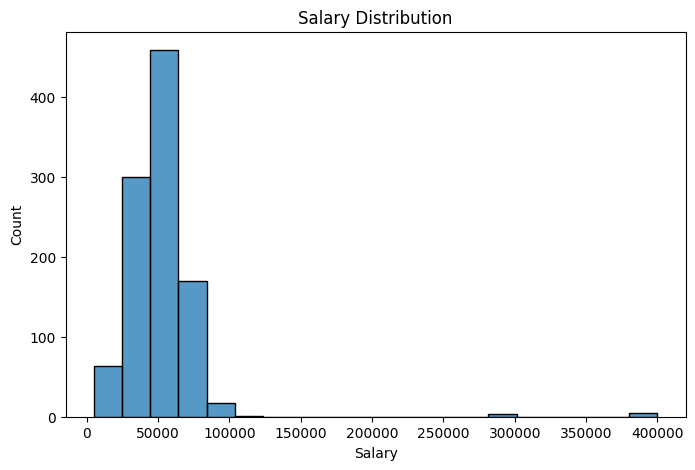

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Salary"], bins=20)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.show()

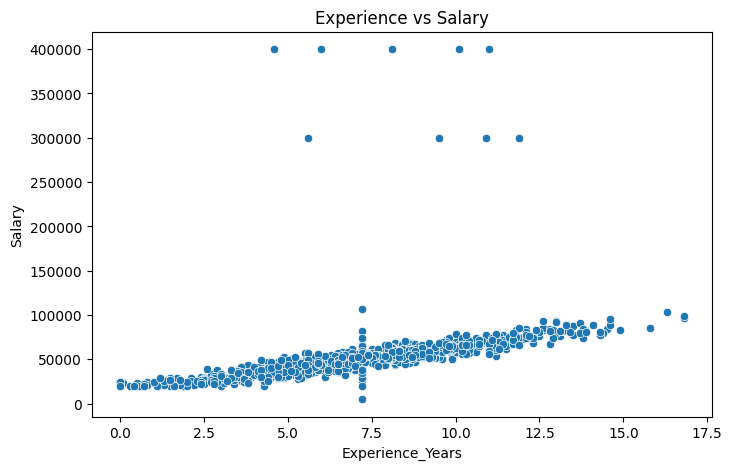

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Experience_Years",
    y="Salary",
    data=df
)

plt.title("Experience vs Salary")
plt.show()

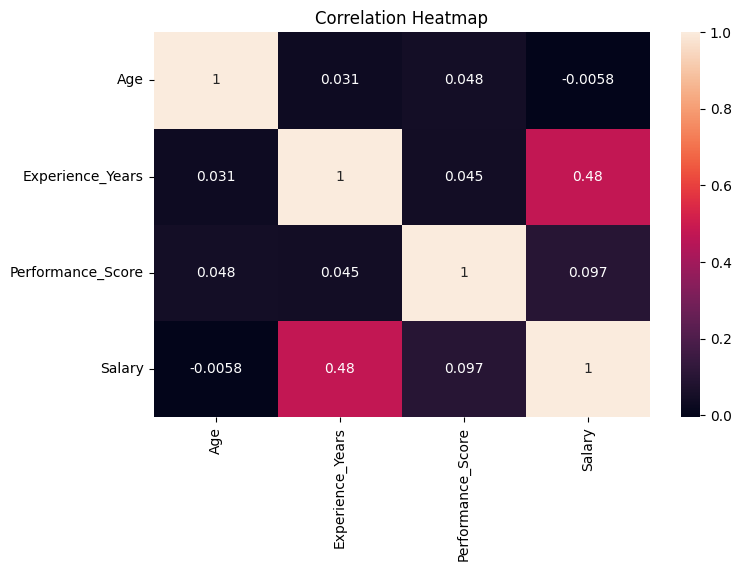

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

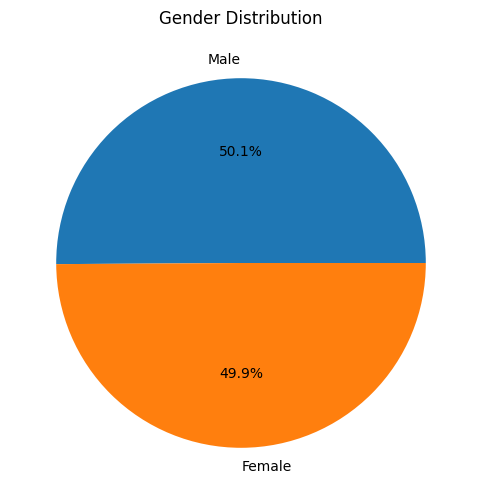

In [ ]:
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")
plt.show()